# Hyperparameter Tuning

The previous notebooks identified Logistic Regression as the best-performing model based on cross-validation.

In this notebook, Logistic Regression is further optimized using RandomizedSearchCV with Stratified 5-Fold Cross-Validation.

The tuned model is evaluated on the unseen test set and compared with the baseline Logistic Regression model. The better-performing model is then selected as the final model for customer churn prediction.

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import (
    StratifiedKFold,
    RandomizedSearchCV
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay
)

## Load Data

In [23]:
X_train = pd.read_csv("X_train_processed.csv")
X_test = pd.read_csv("X_test_processed.csv")

y_train = pd.read_csv("y_train.csv").squeeze()
y_test = pd.read_csv("y_test.csv").squeeze()

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Training Shape : (5634, 50)
Testing Shape  : (1409, 50)


## Train Baseline Logistic Regression

In [24]:
baseline_model = LogisticRegression(
    random_state=42,
    max_iter=5000
)

baseline_model.fit(X_train, y_train)

LogisticRegression(max_iter=5000, random_state=42)

## Hyperparameter Search Space

In [25]:
param_dist = {

    "C": np.logspace(-4,4,30),

    "penalty":["l1","l2"],

    "solver":["liblinear","saga"],

    "max_iter":[1000,3000,5000]

}

## Create Stratified K-Fold Cross Validation

In [26]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

## Randomized Search

In [27]:
random_search = RandomizedSearchCV(

    estimator=LogisticRegression(random_state=42),

    param_distributions=param_dist,

    n_iter=20,

    scoring="roc_auc",

    cv=cv,

    random_state=42,

    verbose=2,

    n_jobs=-1

)

## Train the Tuned Model

In [28]:
random_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=LogisticRegression(random_state=42), n_iter=20,
                   n_jobs=-1,
                   param_distributions={'C': array([1.00000000e-04, 1.88739182e-04, 3.56224789e-04, 6.72335754e-04,
       1.26896100e-03, 2.39502662e-03, 4.52035366e-03, 8.53167852e-03,
       1.61026203e-02, 3.03919538e-02, 5.73615251e-02, 1.082636...
       2.04335972e-01, 3.85662042e-01, 7.27895384e-01, 1.37382380e+00,
       2.59294380e+00, 4.89390092e+00, 9.23670857e+00, 1.74332882e+01,
       3.29034456e+01, 6.21016942e+01, 1.17210230e+02, 2.21221629e+02,
       4.17531894e+02, 7.88046282e+02, 1.48735211e+03, 2.80721620e+03,
       5.29831691e+03, 1.00000000e+04]),
                                        'max_iter': [1000, 3000, 5000],
                                        'penalty': ['l1', 'l2'],
                                        'solver': ['liblinear', 'saga']},
                   random_state=42, scoring='roc_auc', verbose=2)

## Best Parameters

In [29]:
print("Best Hyperparameters:\n")

print(random_search.best_params_)

Best Hyperparameters:

{'solver': 'liblinear', 'penalty': 'l2', 'max_iter': 3000, 'C': np.float64(10000.0)}


## Best Cross-Validation Score

In [30]:
print("Best ROC-AUC:")
print(random_search.best_score_)

Best ROC-AUC:
0.8585848014685249


## Retrieve Best Model

In [31]:
best_model = random_search.best_estimator_

## Predictions

In [33]:
# BASELINE
baseline_pred = baseline_model.predict(X_test)

baseline_prob = baseline_model.predict_proba(X_test)[:,1]

#TUNED
tuned_pred = best_model.predict(X_test)

tuned_prob = best_model.predict_proba(X_test)[:,1]

## Evaluate Both Models

### Baseline

In [34]:
baseline_metrics = {

    "Accuracy":accuracy_score(y_test,baseline_pred),

    "Precision":precision_score(y_test,baseline_pred),

    "Recall":recall_score(y_test,baseline_pred),

    "F1 Score":f1_score(y_test,baseline_pred),

    "ROC-AUC":roc_auc_score(y_test,baseline_prob)

}

### Tuned

In [35]:
tuned_metrics = {

    "Accuracy":accuracy_score(y_test,tuned_pred),

    "Precision":precision_score(y_test,tuned_pred),

    "Recall":recall_score(y_test,tuned_pred),

    "F1 Score":f1_score(y_test,tuned_pred),

    "ROC-AUC":roc_auc_score(y_test,tuned_prob)

}

## Comparison Table

In [36]:
comparison = pd.DataFrame({

    "Metric":baseline_metrics.keys(),

    "Baseline Logistic Regression":baseline_metrics.values(),

    "Tuned Logistic Regression":tuned_metrics.values()

})

comparison = comparison.round(4)

comparison

,Metric,Baseline Logistic Regression,Tuned Logistic Regression
0,Accuracy,0.8013,0.7956
1,Precision,0.6407,0.6280
2,Recall,0.5722,0.5642
3,F1 Score,0.6045,0.5944
4,ROC-AUC,0.8478,0.8467


## Classification Report

In [37]:
print("Baseline Logistic Regression\n")

print(classification_report(y_test,baseline_pred))

print("="*60)

print("Tuned Logistic Regression\n")

print(classification_report(y_test,tuned_pred))

Baseline Logistic Regression

              precision    recall  f1-score   support

           0       0.85      0.88      0.87      1035
           1       0.64      0.57      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409

Tuned Logistic Regression

              precision    recall  f1-score   support

           0       0.85      0.88      0.86      1035
           1       0.63      0.56      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



## Confusion Matrix

### Baseline

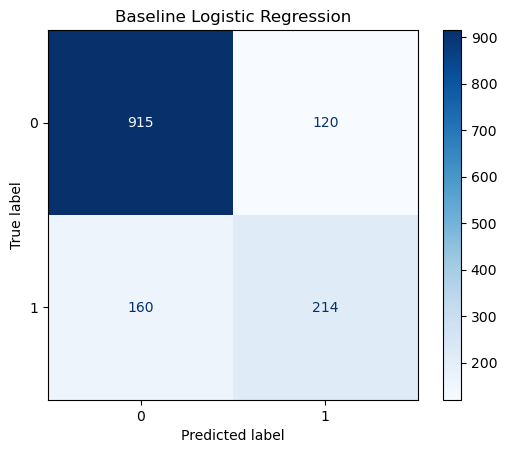

In [38]:
ConfusionMatrixDisplay.from_estimator(

    baseline_model,

    X_test,

    y_test,

    cmap="Blues"

)

plt.title("Baseline Logistic Regression")

plt.show()

### Tuned

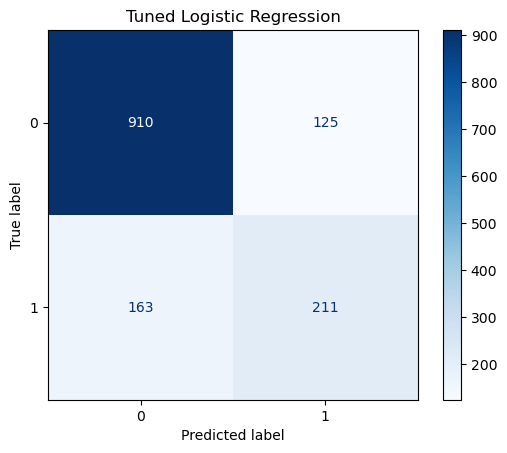

In [39]:
ConfusionMatrixDisplay.from_estimator(

    best_model,

    X_test,

    y_test,

    cmap="Blues"

)

plt.title("Tuned Logistic Regression")

plt.show()

## Feature Importance

In [40]:
importance = pd.DataFrame({

    "Feature":X_train.columns,

    "Coefficient":baseline_model.coef_[0]

})

importance["Absolute Coefficient"] = importance["Coefficient"].abs()

importance = importance.sort_values(

    by="Absolute Coefficient",

    ascending=False

)

importance.head(15)

,Feature,Coefficient,Absolute Coefficient
2,num__Tenure Months,-1.245551,1.245551
14,cat__Dependents_Yes,-0.949155,0.949155
43,cat__Contract_Two year,-0.726276,0.726276
13,cat__Dependents_No,0.673133,0.673133
41,cat__Contract_Month-to-month,0.593869,0.593869
20,cat__Internet Service_DSL,-0.584236,0.584236
21,cat__Internet Service_Fiber optic,0.571261,0.571261
4,num__Total Charges,0.497169,0.497169
3,num__Monthly Charges,-0.494120,0.494120
44,cat__Paperless Billing_No,-0.317907,0.317907


## Final Model Selection

The tuned Logistic Regression model was compared with the baseline Logistic Regression on the held-out test set.

Although RandomizedSearchCV explored multiple hyperparameter combinations using Stratified 5-Fold Cross-Validation, the tuned model did not outperform the baseline model on the unseen test data.

Therefore, the baseline Logistic Regression was selected as the final model because it achieved better overall predictive performance while remaining simple and interpretable.

## Save Final Model

In [ ]:
joblib.dump(

    baseline_model,

    "final_logistic_regression_model.pkl"

)

print("Final model saved successfully.")

## Save Comparison Results

In [41]:
comparison.to_csv(

    "baseline_vs_tuned_logistic_regression.csv",

    index=False

)

print("Comparison table saved successfully.")

Comparison table saved successfully.


## Key Takeaways

- Logistic Regression was selected based on superior cross-validation performance.
- Hyperparameter tuning was performed using RandomizedSearchCV with Stratified 5-Fold Cross-Validation.
- The tuned model was evaluated on the unseen test set.
- The baseline Logistic Regression achieved slightly better test-set performance.
- Therefore, the baseline Logistic Regression was retained as the final model.

# Conclusion

Hyperparameter tuning was performed on Logistic Regression using RandomizedSearchCV with Stratified 5-Fold Cross-Validation.

The tuned model was evaluated on the unseen test set and compared with the baseline Logistic Regression model.

Although the hyperparameter search identified the optimal configuration within the defined search space, the tuned model did not improve upon the baseline model on the test set.

Therefore, the baseline Logistic Regression was retained as the final model for customer churn prediction due to its superior predictive performance, simplicity, and interpretability.